# STEP1 DATA LOADING

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_PATH = "cdc_train.csv"
TEST_PATH  = "test.csv"   # exact filename from your folder

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("Train has price?", "price" in train_df.columns)
print("Test has price?", "price" in test_df.columns)


Train shape: (16209, 21)
Test shape : (5404, 20)
Train has price? True
Test has price? False


# EDA ANALYSIS

In [3]:
train_df.sample(5)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
12338,7525100060,20140820T000000,497000,4,2.25,2250,3463,2.0,0,0,...,8,2250,0,1968,0,98052,47.6324,-122.106,1850,2811
11836,5075400035,20140627T000000,280000,1,1.00,690,1950,1.0,0,0,...,6,690,0,1928,0,98117,47.6849,-122.374,1650,4864
11739,7203140220,20150116T000000,389700,3,2.50,1720,3581,2.0,0,0,...,7,1720,0,2011,0,98053,47.6861,-122.013,1720,3600
12227,3574800010,20150428T000000,485000,4,2.75,1830,8384,1.0,0,0,...,7,1320,510,1979,0,98034,47.7330,-122.220,2190,7695
11140,9358400080,20140627T000000,550000,4,3.50,4150,16197,2.0,0,0,...,10,4150,0,2006,0,98003,47.3423,-122.183,3618,15210


In [4]:
test_df.sample(5)

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5145,1938000140,20150428T000000,4,2.00,2920,10424,1.0,0,0,5,8,1520,1400,1964,0,98005,47.5876,-122.172,2360,10696
1221,2473480560,20140904T000000,3,2.25,2470,10290,2.0,0,0,3,8,2230,240,1984,0,98058,47.4459,-122.124,1970,10150
5283,2924069132,20140527T000000,3,1.75,2310,78844,1.0,0,0,3,8,1760,550,1977,0,98027,47.5406,-122.066,2830,6230
3203,3387900390,20141007T000000,3,1.75,1410,9315,1.0,0,0,5,7,1410,0,1960,0,98031,47.3969,-122.198,1630,8250
3277,2822049160,20150417T000000,3,1.75,1120,10187,1.0,0,0,3,7,1120,0,1968,0,98198,47.3694,-122.311,1900,8736


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5404 entries, 0 to 5403
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             5404 non-null   int64  
 1   date           5404 non-null   object 
 2   bedrooms       5404 non-null   int64  
 3   bathrooms      5404 non-null   float64
 4   sqft_living    5404 non-null   int64  
 5   sqft_lot       5404 non-null   int64  
 6   floors         5404 non-null   float64
 7   waterfront     5404 non-null   int64  
 8   view           5404 non-null   int64  
 9   condition      5404 non-null   int64  
 10  grade          5404 non-null   int64  
 11  sqft_above     5404 non-null   int64  
 12  sqft_basement  5404 non-null   int64  
 13  yr_built       5404 non-null   int64  
 14  yr_renovated   5404 non-null   int64  
 15  zipcode        5404 non-null   int64  
 16  lat            5404 non-null   float64
 17  long           5404 non-null   float64
 18  sqft_liv

In [7]:
train_df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
train_df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.620900e+04,1.620900e+04,16209.00000,16209.000000,16209.000000,1.620900e+04,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000
mean,4.575771e+09,5.374703e+05,3.36782,2.113054,2073.274601,1.486767e+04,1.498828,0.006971,0.234253,3.407860,7.652971,1784.754396,288.520205,1971.152755,82.738108,98077.974767,47.560707,-122.214003,1983.152261,12735.572707
std,2.874661e+09,3.603036e+05,0.93327,0.765242,907.009491,3.882570e+04,0.543032,0.083206,0.763152,0.651553,1.171050,821.820844,438.598910,29.372698,397.861148,53.355282,0.138340,0.140093,681.905161,26933.162012
min,1.000102e+06,7.500000e+04,0.00000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.159300,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.200000e+05,3.00000,1.500000,1430.000000,5.004000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1952.000000,0.000000,98033.000000,47.472500,-122.328000,1480.000000,5098.000000
50%,3.904950e+09,4.500000e+05,3.00000,2.250000,1910.000000,7.599000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.572400,-122.230000,1840.000000,7620.000000
75%,7.304301e+09,6.400000e+05,4.00000,2.500000,2550.000000,1.063100e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2200.000000,560.000000,1997.000000,0.000000,98117.000000,47.678200,-122.125000,2360.000000,10053.000000
max,9.900000e+09,7.700000e+06,33.00000,8.000000,12050.000000,1.164794e+06,3.500000,1.000000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
train_df.duplicated().sum()

0

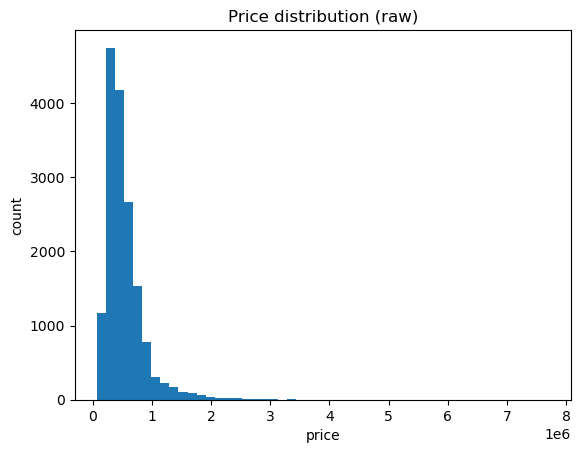

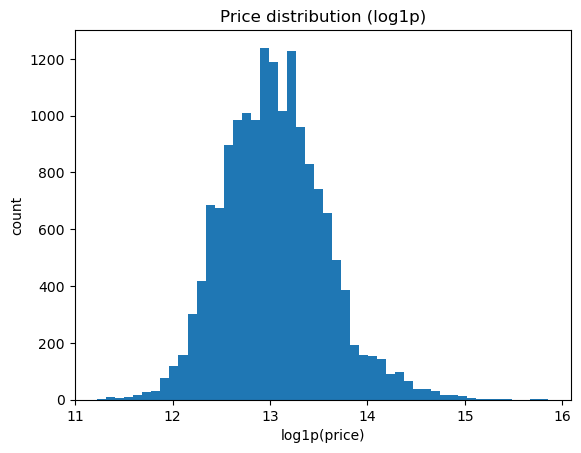

Price percentiles:


0.01     154536.0
0.05     210000.0
0.10     245000.0
0.25     320000.0
0.50     450000.0
0.75     640000.0
0.90     882650.8
0.95    1150000.0
0.99    1944600.0
Name: price, dtype: float64

In [10]:
if "price" in train_df.columns:
    y = train_df["price"]

    plt.figure()
    plt.hist(y, bins=50)
    plt.title("Price distribution (raw)")
    plt.xlabel("price")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    plt.hist(np.log1p(y), bins=50)
    plt.title("Price distribution (log1p)")
    plt.xlabel("log1p(price)")
    plt.ylabel("count")
    plt.show()

    print("Price percentiles:")
    display(y.quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


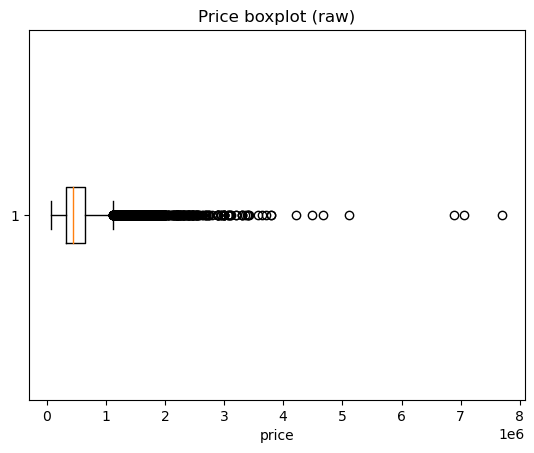

In [11]:
if "price" in train_df.columns:
    plt.figure()
    plt.boxplot(train_df["price"], vert=False)
    plt.title("Price boxplot (raw)")
    plt.xlabel("price")
    plt.show()


In [12]:
train_df.drop("date", axis=1)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,378000,3,1.50,1000,6914,1.0,0,0,3,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
16205,9578500790,399950,3,2.50,3087,5002,2.0,0,0,3,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
16206,7202350480,575000,3,2.50,2120,4780,2.0,0,0,3,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
16207,1723049033,245000,1,0.75,380,15000,1.0,0,0,3,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [13]:
test_df.drop("date",axis=1)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2591820310,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
1,7974200820,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
2,7701450110,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
3,9522300010,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
4,9510861140,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,7732500270,4,2.50,2820,15000,2.0,0,0,4,9,2820,0,1985,0,98052,47.7255,-122.101,2440,15000
5400,3856903515,3,2.00,1460,6250,1.5,0,0,4,7,1460,0,1912,0,98103,47.6693,-122.333,1690,4750
5401,2557000400,3,2.50,2070,9900,1.0,0,0,3,8,1420,650,1979,0,98023,47.2988,-122.371,2070,8250
5402,4386700135,4,2.25,4760,8036,2.5,0,0,5,9,3390,1370,1916,0,98112,47.6415,-122.285,2950,9323


In [14]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

if "price" in numeric_cols:
    corr = (
        train_df[numeric_cols]
        .corr()
        .loc[:, "price"]      # <-- ensures Series
        .sort_values(ascending=False)
    )

    display(corr)

    top = corr.drop("price").head(12)


price            1.000000
sqft_living      0.700933
grade            0.664266
sqft_above       0.602648
sqft_living15    0.581781
bathrooms        0.525487
view             0.390534
sqft_basement    0.320301
lat              0.310008
bedrooms         0.304454
floors           0.251428
waterfront       0.245221
yr_renovated     0.133075
sqft_lot         0.088526
sqft_lot15       0.076060
yr_built         0.048307
condition        0.031333
long             0.024279
id              -0.020260
zipcode         -0.054517
Name: price, dtype: float64

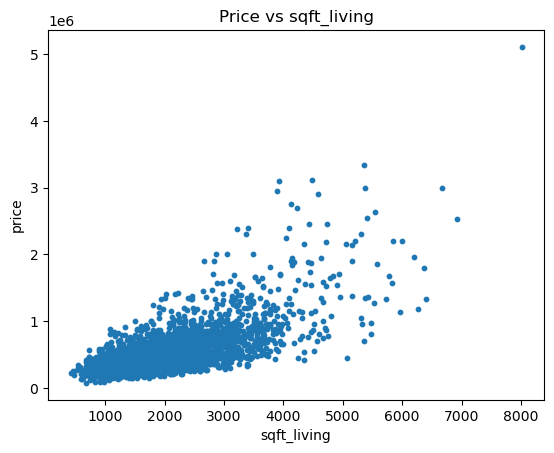

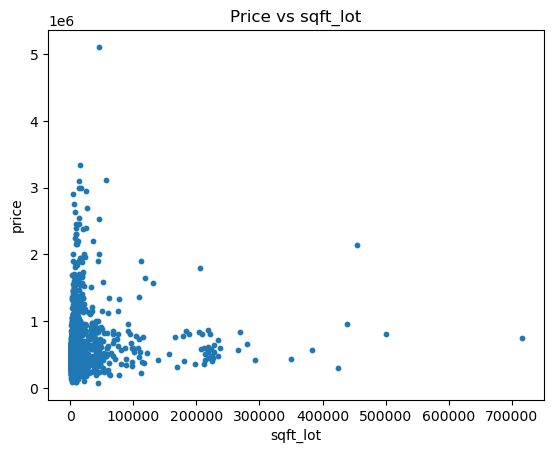

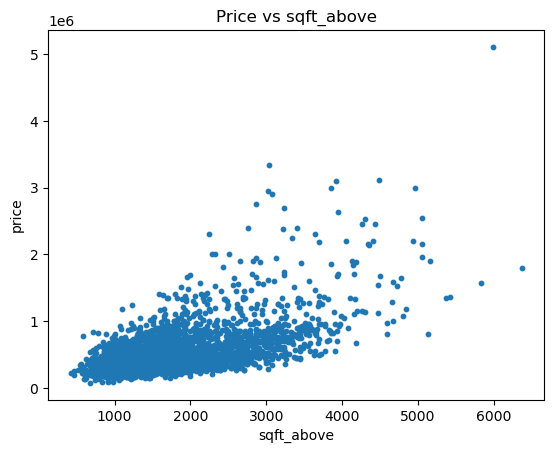

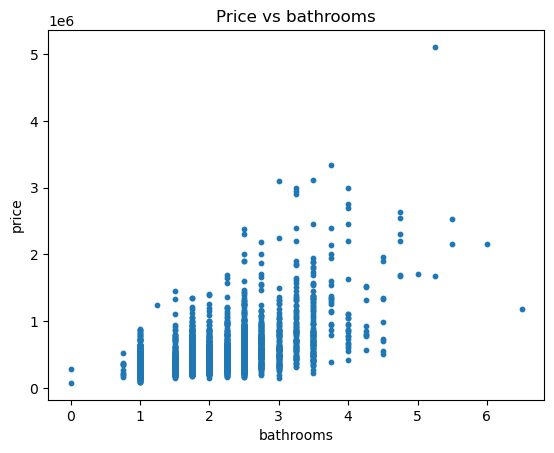

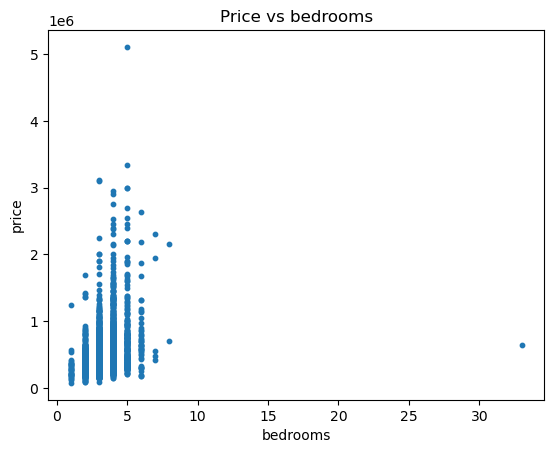

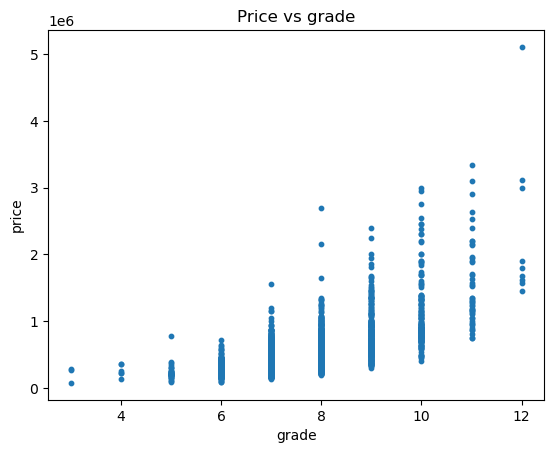

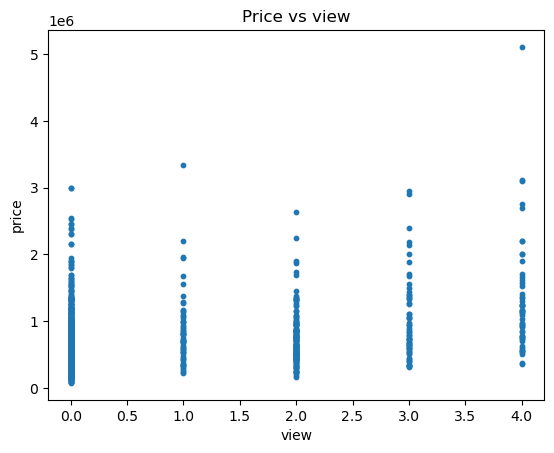

In [15]:
if "price" in train_df.columns:
    def scatter_price(col, sample=3000):
        df = train_df[[col, "price"]].dropna()
        if len(df) > sample:
            df = df.sample(sample, random_state=42)

        plt.figure()
        plt.scatter(df[col], df["price"], s=10)
        plt.title(f"Price vs {col}")
        plt.xlabel(col)
        plt.ylabel("price")
        plt.show()

    for col in ["sqft_living", "sqft_lot", "sqft_above", "bathrooms", "bedrooms", "grade", "view"]:
        if col in train_df.columns:
            scatter_price(col)


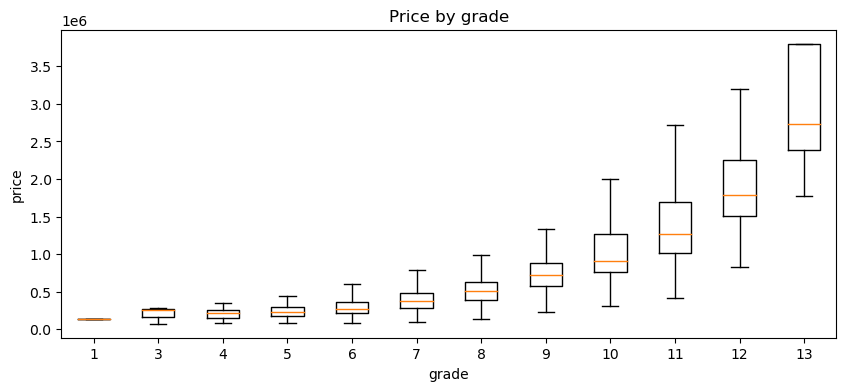

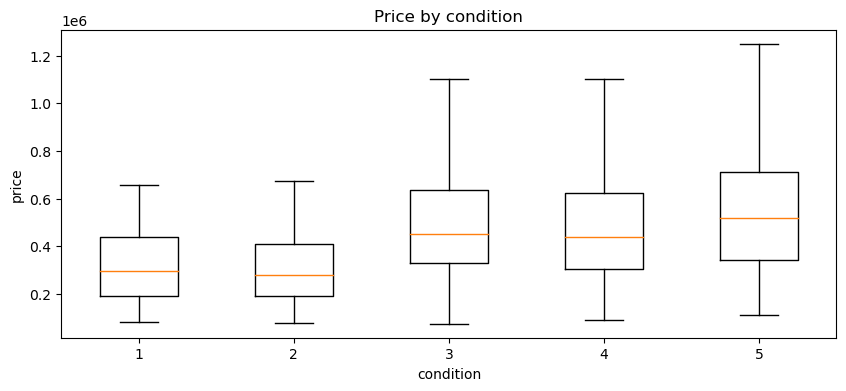

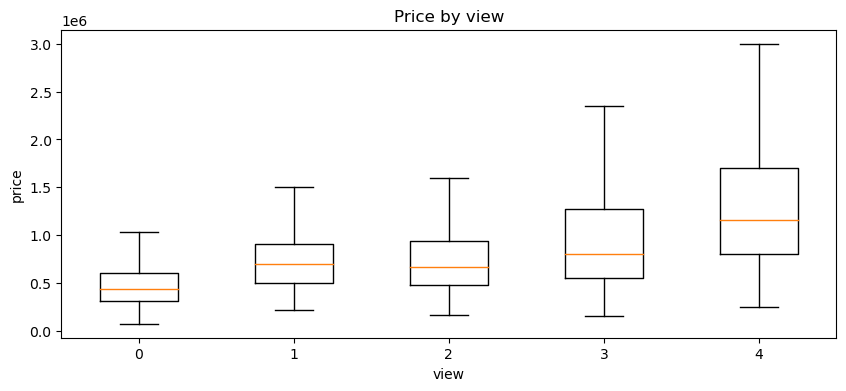

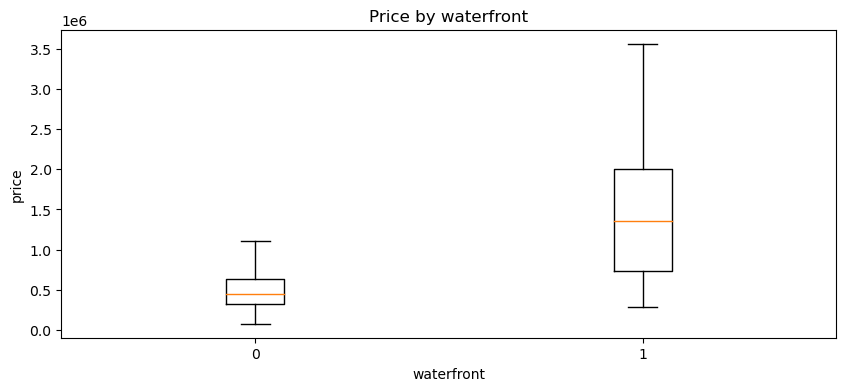

In [16]:
if "price" in train_df.columns:
    def box_price(col):
        df = train_df[[col, "price"]].dropna()
        df[col] = df[col].astype(int)

        groups = [df[df[col] == v]["price"].values for v in sorted(df[col].unique())]

        plt.figure(figsize=(10,4))
        plt.boxplot(groups, labels=sorted(df[col].unique()), showfliers=False)
        plt.title(f"Price by {col}")
        plt.xlabel(col)
        plt.ylabel("price")
        plt.show()

    for col in ["grade", "condition", "view", "waterfront"]:
        if col in train_df.columns:
            box_price(col)


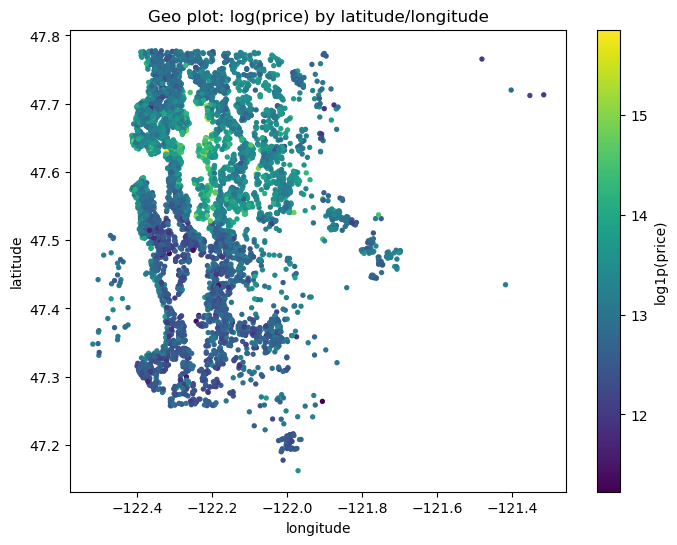

In [17]:
if "price" in train_df.columns:
    df_geo = train_df[["lat", "long", "price"]].dropna()

    # sample for speed
    if len(df_geo) > 6000:
        df_geo = df_geo.sample(6000, random_state=42)

    plt.figure(figsize=(8,6))
    plt.scatter(df_geo["long"], df_geo["lat"], c=np.log1p(df_geo["price"]), s=8)
    plt.title("Geo plot: log(price) by latitude/longitude")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.colorbar(label="log1p(price)")
    plt.show()


,count,mean,median
zipcode,,,
98039,37,2.055931e+06,1905000.0
98004,235,1.328961e+06,1110000.0
98040,204,1.198328e+06,997000.0
98112,207,1.098366e+06,940000.0
98102,79,9.336901e+05,690000.0
98006,380,8.769559e+05,779500.0
98119,142,8.562714e+05,740000.0
98109,81,8.528373e+05,716000.0
98105,176,8.325499e+05,665000.0


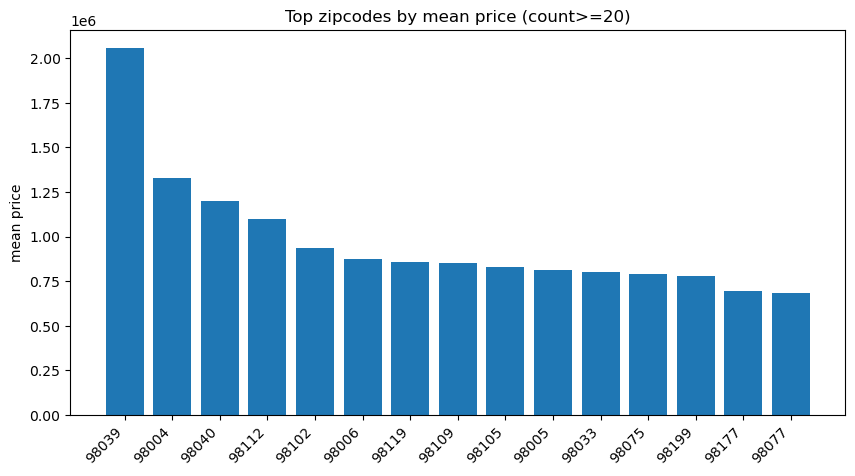

In [18]:
if "price" in train_df.columns and "zipcode" in train_df.columns:
    zip_stats = train_df.groupby("zipcode")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
    display(zip_stats.head(15))

    # Plot top 15 zipcodes by mean price (only those with enough samples)
    zip_stats_f = zip_stats[zip_stats["count"] >= 20].head(15)

    plt.figure(figsize=(10,5))
    plt.bar(zip_stats_f.index.astype(str), zip_stats_f["mean"])
    plt.title("Top zipcodes by mean price (count>=20)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("mean price")
    plt.show()


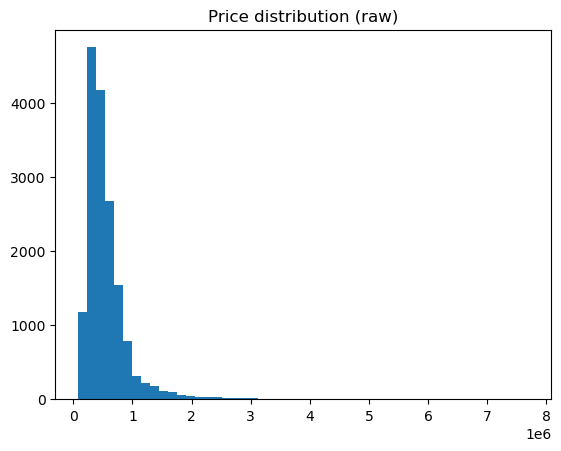

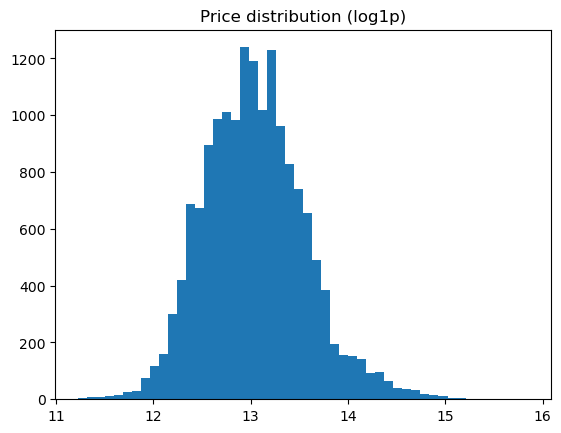

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.hist(train_df["price"], bins=50)
plt.title("Price distribution (raw)")
plt.show()

plt.figure()
plt.hist(np.log1p(train_df["price"]), bins=50)
plt.title("Price distribution (log1p)")
plt.show()


In [20]:
from scipy.stats import skew

raw_skew = skew(train_df["price"].dropna())
log_skew = skew(np.log1p(train_df["price"].dropna()))

print("Skew raw  :", raw_skew)
print("Skew log1p:", log_skew)


Skew raw  : 4.032689113561292
Skew log1p: 0.4114949564658959


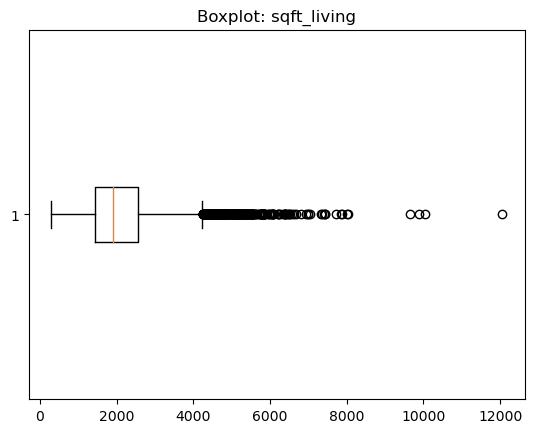

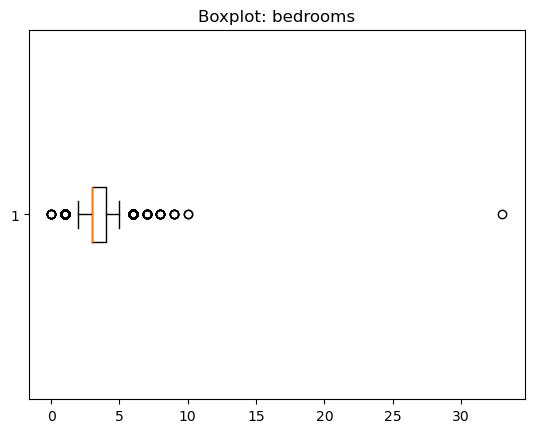

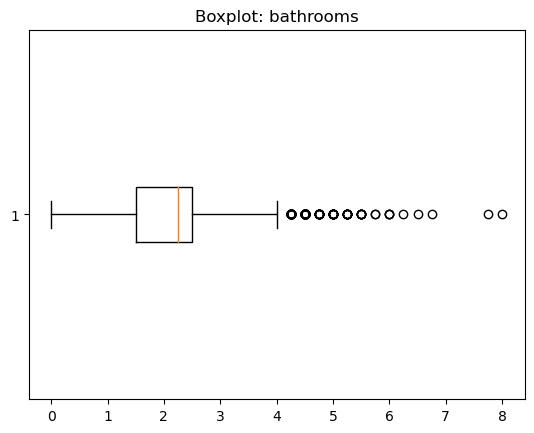

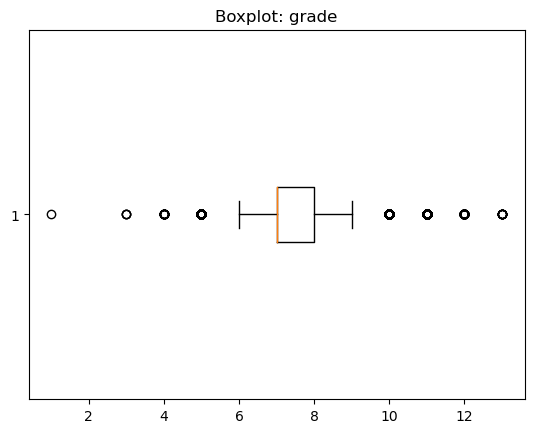

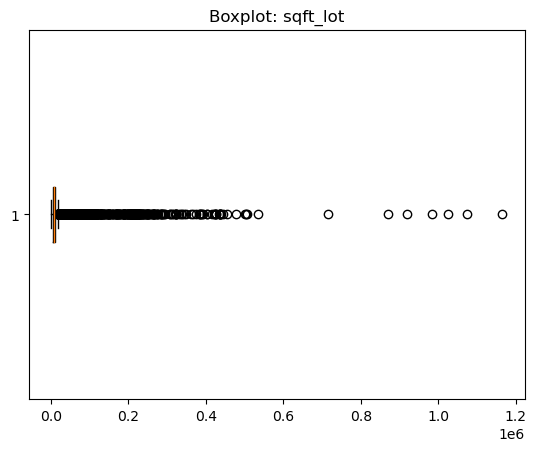

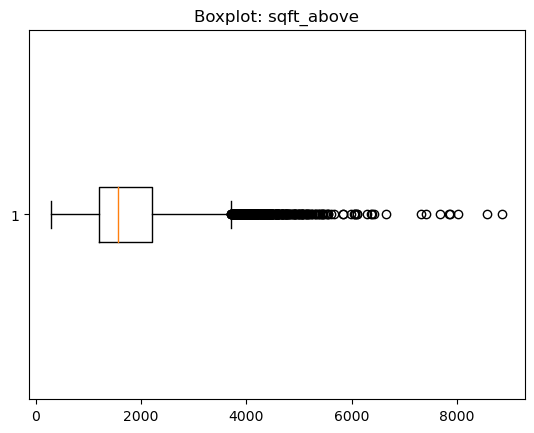

In [21]:
cols = ["sqft_living","bedrooms","bathrooms","grade","sqft_lot","sqft_above"]
for c in cols:
    if c in train_df.columns:
        plt.figure()
        plt.boxplot(train_df[c].dropna(), vert=False)
        plt.title(f"Boxplot: {c}")
        plt.show()


In [22]:
cols = ["price","bedrooms","bathrooms","sqft_living","sqft_lot","sqft_above","sqft_basement","floors","grade","view","lat","long"]
train_df[cols].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).T

,count,mean,std,min,50%,95%,99%,99.5%,99.9%,max
price,16209.0,537470.282744,360303.577357,75000.0000,450000.0000,1.150000e+06,1.944600e+06,2.399400e+06,3.335640e+06,7.700000e+06
bedrooms,16209.0,3.367820,0.933270,0.0000,3.0000,5.000000e+00,6.000000e+00,6.000000e+00,7.792000e+00,3.300000e+01
bathrooms,16209.0,2.113054,0.765242,0.0000,2.2500,3.500000e+00,4.250000e+00,4.500000e+00,5.250000e+00,8.000000e+00
sqft_living,16209.0,2073.274601,907.009491,290.0000,1910.0000,3.740000e+03,4.920000e+03,5.509200e+03,6.969600e+03,1.205000e+04
sqft_lot,16209.0,14867.673145,38825.702074,520.0000,7599.0000,4.301020e+04,2.130080e+05,2.473687e+05,4.356000e+05,1.164794e+06
sqft_above,16209.0,1784.754396,821.820844,290.0000,1560.0000,3.390000e+03,4.380000e+03,4.750000e+03,6.065840e+03,8.860000e+03
sqft_basement,16209.0,288.520205,438.598910,0.0000,0.0000,1.170000e+03,1.650000e+03,1.830000e+03,2.325840e+03,4.820000e+03
floors,16209.0,1.498828,0.543032,1.0000,1.5000,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.500000e+00
grade,16209.0,7.652971,1.171050,1.0000,7.0000,1.000000e+01,1.100000e+01,1.100000e+01,1.200000e+01,1.300000e+01
view,16209.0,0.234253,0.763152,0.0000,0.0000,2.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00


In [23]:
train_base = train_df.copy()
test_base  = test_df.copy()

train_base["zipcode"] = train_base["zipcode"].astype(str)
test_base["zipcode"]  = test_base["zipcode"].astype(str)


# Feature Engineering

In [24]:
import pandas as pd
import numpy as np

def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---- date features ----
    # robust parse: works for YYYYMMDD or string
    dt = pd.to_datetime(df["date"].astype(str), errors="coerce")
    df["sale_year"]  = dt.dt.year
    df["sale_month"] = dt.dt.month
    df["sale_day"]   = dt.dt.day
    df.drop(columns=["date"], inplace=True)  # optional: drop raw date

    # ---- renovation & age ----
    df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)
    df["house_age"] = df["sale_year"] - df["yr_built"]

    # If renovated, years since renovation, else NaN
    df["years_since_reno"] = np.where(df["yr_renovated"] > 0,
                                      df["sale_year"] - df["yr_renovated"],
                                      np.nan)

    # ---- size/ratio features ----
    df["living_to_lot"] = df["sqft_living"] / (df["sqft_lot"] + 1)
    df["above_to_living"] = df["sqft_above"] / (df["sqft_living"] + 1)
    df["basement_to_living"] = df["sqft_basement"] / (df["sqft_living"] + 1)

    # ---- neighborhood comparison features ----
    df["living_vs_15"] = df["sqft_living"] - df["sqft_living15"]
    df["lot_vs_15"]    = df["sqft_lot"]    - df["sqft_lot15"]

    # ---- simple interaction feature ----
    df["bed_bath_interaction"] = df["bedrooms"] * df["bathrooms"]

    return df

train_fe = feature_engineer(train_base)
test_fe  = feature_engineer(test_base)

print(train_fe.shape, test_fe.shape)
train_fe.head()


(16209, 32) (5404, 31)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sale_day,is_renovated,house_age,years_since_reno,living_to_lot,above_to_living,basement_to_living,living_vs_15,lot_vs_15,bed_bath_interaction
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,...,5,0,54,NaN,0.195866,0.999448,0.000000,150,0,9.0
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,...,8,0,22,NaN,0.573682,0.999375,0.000000,-120,-817,7.5
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,...,15,0,21,NaN,0.199097,0.999419,0.000000,-150,1183,10.0
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,...,27,0,6,NaN,1.756374,0.926672,0.072522,0,-45,4.5
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,...,5,0,20,NaN,0.095830,0.999219,0.000000,-310,5285,6.0


In [25]:
df = train_fe.copy()

# Remove impossible values (universal rules)
# df = df[df["bedrooms"] > 0]
# df = df[df["bathrooms"] > 0]
# df = df[df["sqft_living"] > 0]
# df = df[df["sqft_lot"] > 0]
# df = df[df["floors"] > 0]

# print("Before:", train_fe.shape, "After:", df.shape)


# Winsorisation

In [26]:
clip_cols = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "sqft_living15", "sqft_lot15"]

df_clip = df.copy()

caps = {}
for c in clip_cols:
    lo = df_clip[c].quantile(0.01)
    hi = df_clip[c].quantile(0.99)
    caps[c] = (lo, hi)
    df_clip[c] = df_clip[c].clip(lo, hi)

caps  # shows the actual lower/upper caps from YOUR data


{'sqft_living': (720.0, 4920.0),
 'sqft_lot': (1005.0, 213008.0),
 'sqft_above': (700.0, 4380.0),
 'sqft_basement': (0.0, 1650.0),
 'sqft_living15': (950.0, 4049.3600000000006),
 'sqft_lot15': (1188.08, 169436.3600000001)}

In [27]:
# copy test dataframe
test_df_clip = test_fe.copy()

# apply train caps to test data
for c in clip_cols:
    lo, hi = caps[c]          # use TRAIN quantiles
    test_df_clip[c] = test_df_clip[c].clip(lo, hi)


In [28]:
print(train_df["zipcode"].nunique(), "unique zipcodes")
print(train_df["zipcode"].dtype)


70 unique zipcodes
int64


## converting zipcode to str and then One Hot Encoding

In [29]:
# Make zipcode categorical (IMPORTANT)
df_clip["zipcode"] = train_fe["zipcode"].astype(str)
test_df_clip["zipcode"]  = test_fe["zipcode"].astype(str)

# Quick check for unseen zipcodes in test
unseen = set(test_fe["zipcode"].unique()) - set(train_fe["zipcode"].unique())
print("Unseen zipcodes in test:", len(unseen))


Unseen zipcodes in test: 0


In [30]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Assumption: you've already done:
# train_df["zipcode"] = train_df["zipcode"].astype(str)
# test_df["zipcode"]  = test_df["zipcode"].astype(str)

# 1) Fit OHE on train zipcode, transform both train and test
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

zip_train = ohe.fit_transform(df_clip[["zipcode"]])
zip_test  = ohe.transform(test_df_clip[["zipcode"]])

zip_cols = ohe.get_feature_names_out(["zipcode"])

zip_train_df = pd.DataFrame(zip_train, columns=zip_cols, index=df_clip.index)
zip_test_df  = pd.DataFrame(zip_test,  columns=zip_cols, index=test_df_clip.index)

# 2) Replace zipcode column with OHE columns
train_df_ohe = pd.concat([df_clip.drop(columns=["zipcode"]), zip_train_df], axis=1)
test_df_ohe  = pd.concat([test_df_clip.drop(columns=["zipcode"]),  zip_test_df], axis=1)

print("Old shapes:", df_clip.shape, test_df_clip.shape)
print("New shapes:", train_df_ohe.shape, test_df_ohe.shape)

# (Optional) confirm zipcode removed
print("zipcode in train_df_ohe?", "zipcode" in train_df_ohe.columns)
print("zipcode in test_df_ohe?", "zipcode" in test_df_ohe.columns)

# View a few new OHE columns
train_df_ohe.filter(like="zipcode_").head()


Old shapes: (16209, 32) (5404, 31)
New shapes: (16209, 101) (5404, 100)
zipcode in train_df_ohe? False
zipcode in test_df_ohe? False


,zipcode_98001,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Converting ID column to INT

In [31]:
#CONVERTING ID TO INT
# IMPORTANT: overwrite id from the ORIGINAL dfs (correct ids)
train_df_ohe = train_df_ohe.copy()
test_df_ohe  = test_df_ohe.copy()

train_df_ohe["id"] = train_df["id"].astype(str).values
test_df_ohe["id"]  = test_df["id"].astype(str).values

# quick sanity checks
print("Bad ids count:", (train_df_ohe["id"].str.startswith("-")).sum())
print("Null ids count:", train_df_ohe["id"].isna().sum())
print(train_df_ohe["id"].head())


Bad ids count: 0
Null ids count: 0
0    9117000170
1    6700390210
2    7212660540
3    8562780200
4    7760400350
Name: id, dtype: object


### Checking NAN values in the final dataset, if there fill with medians

In [32]:
import numpy as np

def clean_tabular(df, feature_cols, medians=None):
    df = df.copy()

    # replace inf/-inf with NaN
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

    if medians is None:
        medians = df[feature_cols].median(numeric_only=True)

    df[feature_cols] = df[feature_cols].fillna(medians)

    return df, medians

# feature_cols from earlier (excluding id, price)
feature_cols = [c for c in train_df_ohe.columns if c not in ["id", "price"]]

train_df_ohe_clean, medians = clean_tabular(train_df_ohe, feature_cols, medians=None)
test_df_ohe_clean, _        = clean_tabular(test_df_ohe,  feature_cols, medians=medians)

print("Train NaNs left:", train_df_ohe_clean[feature_cols].isna().sum().sum())
print("Test NaNs left :", test_df_ohe_clean[feature_cols].isna().sum().sum())
#excluding NAN values 

Train NaNs left: 0
Test NaNs left : 0


# MODEL TRAINING FOR TABULAR DATA ONLY


In [33]:
import numpy as np

y = np.log1p(train_df_ohe["price"].values)
X = train_df_ohe.drop(columns=["price"])

X_test = test_df_ohe.copy()

print(X.shape, y.shape, X_test.shape)


(16209, 100) (16209,) (5404, 100)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

model = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=900,
    random_state=42
)

model.fit(X_train, y_train)

val_pred = model.predict(X_val)
print("VAL RMSE (log):", rmse(y_val, val_pred))
print("VAL R2   (log):", r2_score(y_val, val_pred))


VAL RMSE (log): 0.1633243793384752
VAL R2   (log): 0.903335763417612


In [36]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    model, X, y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

cv_r2 = cross_val_score(
    model, X, y,
    scoring="r2",
    cv=kf,
    n_jobs=-1
)

print("CV RMSE (log): mean =", cv_rmse.mean(), "std =", cv_rmse.std())
print("CV R2   (log): mean =", cv_r2.mean(),  "std =", cv_r2.std())


CV RMSE (log): mean = 0.16230389347164645 std = 0.0015315380224696171
CV R2   (log): mean = 0.9038691802161285 std = 0.003528064559056061


### Fitting on full data and then predicted csv file

In [38]:
# Fit on full data
model.fit(X, y)

# Predict test
test_pred_log = model.predict(X_test)
test_pred_price = np.expm1(test_pred_log)

import pandas as pd
submission = pd.DataFrame({
    "id": test_df["id"].values,
    "predicted_price": test_pred_price
})
submission.to_csv("submission_tabular.csv", index=False)
submission.head()


,id,predicted_price
0,2591820310,3.769547e+05
1,7974200820,8.535485e+05
2,7701450110,1.094949e+06
3,9522300010,1.860014e+06
4,9510861140,7.092015e+05


# MULTIMODEL PART

## Image downloading

In [39]:
MAPBOX_TOKEN = "pk.eyJ1Ijoia3Jpc2gtMjMiLCJhIjoiY21rMXRyM2o3MDc3dzNlcXk5NG1hcnVqeSJ9.u31vbVGdr7geuT9Atdbyaw"
STYLE_ID = "mapbox/satellite-streets-v12"  # satellite imagery


In [40]:
import os
os.makedirs("images/train", exist_ok=True)
os.makedirs("images/test", exist_ok=True)


In [41]:
import requests
from tqdm import tqdm

def mapbox_static_url(lat, lon, token, zoom=18, size=224, style_id="mapbox/satellite-streets-v12", scale=1):
    """
    Mapbox Static Images API:
    https://api.mapbox.com/styles/v1/{style_id}/static/{lon},{lat},{zoom}/{w}x{h}?access_token=...
    """
    # Mapbox expects lon,lat order in the path
    return (
        f"https://api.mapbox.com/styles/v1/{style_id}/static/"
        f"{lon},{lat},{zoom}/{size}x{size}"
        f"?access_token={token}"
    )

def download_image(url, save_path, timeout=30):
    r = requests.get(url, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
    with open(save_path, "wb") as f:
        f.write(r.content)

# ---- TEST 10 train images ----
sample = train_df.sample(10, random_state=42)

errors = []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    pid = row["id"]
    lat = row["lat"]
    lon = row["long"]

    out_path = f"images/train/{pid}.png"
    if os.path.exists(out_path):
        continue

    try:
        url = mapbox_static_url(lat, lon, MAPBOX_TOKEN, zoom=18, size=224, style_id=STYLE_ID)
        download_image(url, out_path)
    except Exception as e:
        errors.append((pid, str(e)))

print("Done. Errors:", len(errors))
if errors:
    print("First few errors:", errors[:3])


100%|██████████| 10/10 [00:04<00:00,  2.01it/s]

Done. Errors: 0


In [42]:
import time
import pandas as pd

def download_dataset_images(df, out_dir, token, zoom=18, size=224, style_id="mapbox/satellite-streets-v12",
                            sleep=0.05, max_retries=3):
    os.makedirs(out_dir, exist_ok=True)
    failed = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        pid = row["id"]
        lat = row["lat"]
        lon = row["long"]

        out_path = os.path.join(out_dir, f"{pid}.png")
        if os.path.exists(out_path):
            continue

        url = mapbox_static_url(lat, lon, token, zoom=zoom, size=size, style_id=style_id)

        ok = False
        for attempt in range(max_retries):
            try:
                download_image(url, out_path)
                ok = True
                break
            except Exception as e:
                if attempt == max_retries - 1:
                    failed.append((pid, str(e)))
                time.sleep(1.0)

        time.sleep(sleep)

    return failed

failed_train = download_dataset_images(train_df, "images/train", MAPBOX_TOKEN, zoom=18, size=224, style_id=STYLE_ID)
failed_test  = download_dataset_images(test_df,  "images/test",  MAPBOX_TOKEN, zoom=18, size=224, style_id=STYLE_ID)

pd.DataFrame(failed_train, columns=["id", "error"]).to_csv("failed_train_downloads.csv", index=False)
pd.DataFrame(failed_test,  columns=["id", "error"]).to_csv("failed_test_downloads.csv", index=False)

print("Train failed:", len(failed_train))
print("Test failed :", len(failed_test))
print("Saved failure logs.")


 30%|██▉       | 4856/16209 [34:27<1:20:33,  2.35it/s]


KeyboardInterrupt: 

### Creating a pytorch dattset on train

In [80]:
#Creating a pytorch dattset on train
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# Image transforms (keep it simple for now)
train_img_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Standard ImageNet normalization (good for pretrained CNNs)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class RealEstateTrainDataset(Dataset):
    def __init__(self, df, feature_cols, image_dir, img_transform=None):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.image_dir = image_dir
        self.img_transform = img_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pid = row["id"]
        img_path = os.path.join(self.image_dir, f"{pid}.png")

        # 1) Load image
        img = Image.open(img_path).convert("RGB")
        if self.img_transform:
            img = self.img_transform(img)

        # 2) Tabular features -> float32 tensor
        tab = row[self.feature_cols].values.astype(np.float32)
        tab = torch.tensor(tab, dtype=torch.float32)

        # 3) Target -> log1p(price)
        y = np.log1p(row["price"]).astype(np.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return img, tab, y


### creating a pytorch dataset on test

In [89]:
#creating a pytorch dataset on test
test_img_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class RealEstateTestDataset(Dataset):
    def __init__(self, df, feature_cols, image_dir, img_transform=None):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.image_dir = image_dir
        self.img_transform = img_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pid = row["id"]

        img_path = os.path.join(self.image_dir, f"{pid}.png")

        img = Image.open(img_path).convert("RGB")
        if self.img_transform:
            img = self.img_transform(img)

        tab = row[self.feature_cols].values.astype(np.float32)
        tab = np.nan_to_num(tab, nan=0.0, posinf=0.0, neginf=0.0)

        tab = torch.tensor(tab, dtype=torch.float32)

        return pid, img, tab


### QUICK CHECK

In [108]:
#QUICK CHECK 
train_ds = RealEstateTrainDataset(train_df_ohe_clean, feature_cols, "images/train", train_img_tfms)
test_ds  = RealEstateTestDataset(test_df_ohe_clean, feature_cols, "images/test", test_img_tfms)

img, tab, y = train_ds[0]
print("Train sample:")
print("image:", img.shape, img.dtype)
print("tab  :", tab.shape, tab.dtype)
print("y    :", y, y.dtype)

pid, img2, tab2 = test_ds[0]
print("\nTest sample:")
print("id   :", pid)
print("image:", img2.shape, img2.dtype)
print("tab  :", tab2.shape, tab2.dtype)


Train sample:
image: torch.Size([3, 224, 224]) torch.float32
tab  : torch.Size([99]) torch.float32
y    : tensor(12.5011) torch.float32

Test sample:
id   : 2591820310
image: torch.Size([3, 224, 224]) torch.float32
tab  : torch.Size([99]) torch.float32


### CREATING DATALOADERS(BATCHING)

In [109]:
# CREATING DATALOADERS(BATCHING)
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

# test one batch
imgs, tabs, ys = next(iter(train_loader))
print("Batch shapes:")
print("imgs:", imgs.shape)
print("tabs:", tabs.shape)
print("ys  :", ys.shape)


Batch shapes:
imgs: torch.Size([32, 3, 224, 224])
tabs: torch.Size([32, 99])
ys  : torch.Size([32])


# CNN+TABULAR+FUSION

In [110]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np

idx = np.arange(len(train_ds))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(Subset(train_ds, val_idx),   batch_size=32, shuffle=False, num_workers=0)

print(len(train_idx), len(val_idx))


12967 3242


In [111]:
# CNN encodes image → image embedding
# Small MLP encodes tabular → tab embedding
# Concatenate both embeddings → regression head → predict log(price)
# We’ll use a pretrained CNN (ResNet18) to start. It’s fast and works well.

In [112]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultiModalRegressor(nn.Module):
    def __init__(self, tab_dim: int, img_embed_dim=256, tab_embed_dim=128, dropout=0.2):
        super().__init__()

        # ---- Image encoder (ResNet18) ----
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Replace final classification layer to output img_embed_dim
        in_features = backbone.fc.in_features
        backbone.fc = nn.Linear(in_features, img_embed_dim)
        self.cnn = backbone

        # ---- Tabular encoder (MLP) ----
        self.tab_mlp = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, tab_embed_dim),
            nn.ReLU()
        )

        # ---- Fusion + regression head ----
        self.head = nn.Sequential(
            nn.Linear(img_embed_dim + tab_embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, img, tab):
        img_feat = self.cnn(img)              # (B, img_embed_dim)
        tab_feat = self.tab_mlp(tab)          # (B, tab_embed_dim)
        fused = torch.cat([img_feat, tab_feat], dim=1)
        out = self.head(fused).squeeze(1)     # (B,)
        return out

tab_dim = 99  # from your output
model = MultiModalRegressor(tab_dim=tab_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)


Device: cpu


In [113]:
# We’ll use:
# Loss: MSE on log(price)
# Metric: RMSE on log(price) + (optional) RMSE on original price scale

In [122]:
import numpy as np

def rmse_simple(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2)))


In [123]:
import torch
import numpy as np

def run_one_epoch(loader, train=True):
    model.train() if train else model.eval()

    losses = []
    all_y, all_pred = [], []

    for imgs, tabs, ys in loader:
        imgs = imgs.to(device)
        tabs = tabs.to(device)
        ys   = ys.to(device)

        with torch.set_grad_enabled(train):
            preds = model(imgs, tabs)   # (B,)
            loss = criterion(preds, ys)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stabilizer
                optimizer.step()

        losses.append(loss.item())
        all_y.append(ys.detach().cpu().numpy().reshape(-1))
        all_pred.append(preds.detach().cpu().numpy().reshape(-1))

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    return float(np.mean(losses)), rmse_simple(all_y, all_pred)


In [125]:
from sklearn.metrics import r2_score

def r2_np(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(losses)), rmse_simple(all_y, all_pred), r2_np(all_y, all_pred)


In [126]:
for name, p in model.cnn.named_parameters():
    if "fc" not in name:   # freeze everything except last FC
        p.requires_grad = False


In [127]:
import torch.optim as optim
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=1e-4)


In [128]:
best_val = 1e9
best_state = None
patience = 2
bad = 0

EPOCHS = 15
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_rmse = run_one_epoch(train_loader, train=True)
    va_loss, va_rmse = run_one_epoch(val_loader, train=False)

    print(f"Epoch {epoch:02d} | train rmse(log) {tr_rmse:.4f} | val rmse(log) {va_rmse:.4f}")

    if va_rmse < best_val:
        best_val = va_rmse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
        print("  ✅ saved best")
    else:
        bad += 1
        print("  ⚠️ no improvement")

    if bad >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
model.to(device)
print("Best val rmse(log):", best_val)


Epoch 01 | train rmse(log) 11.2654 | val rmse(log) 1.0929
  ✅ saved best
Epoch 02 | train rmse(log) 3.4996 | val rmse(log) 0.7145
  ✅ saved best
Epoch 03 | train rmse(log) 3.7407 | val rmse(log) 0.6946
  ✅ saved best
Epoch 04 | train rmse(log) 1.4179 | val rmse(log) 0.5703
  ✅ saved best
Epoch 05 | train rmse(log) 1.1581 | val rmse(log) 0.5490
  ✅ saved best
Epoch 06 | train rmse(log) 1.1058 | val rmse(log) 1.7305
  ⚠️ no improvement
Epoch 07 | train rmse(log) 1.2731 | val rmse(log) 0.5464
  ✅ saved best
Epoch 08 | train rmse(log) 1.1073 | val rmse(log) 0.5653
  ⚠️ no improvement
Epoch 09 | train rmse(log) 1.0226 | val rmse(log) 0.5534
  ⚠️ no improvement
Early stopping.
Best val rmse(log): 0.5464062690734863


In [129]:
model.eval()


MultiModalRegressor(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [130]:
import numpy as np
import pandas as pd
import torch

ids = []
preds_price = []

with torch.no_grad():
    for pid, imgs, tabs in test_loader:
        imgs = imgs.to(device)
        tabs = tabs.to(device)

        pred_log = model(imgs, tabs).detach().cpu().numpy().reshape(-1)
        pred = np.expm1(pred_log)  # back to original price

        ids.extend(list(pid))
        preds_price.extend(list(pred))

sub = pd.DataFrame({
    "id": ids,
    "predicted_price": preds_price
})

sub.to_csv("submission_multimodal.csv", index=False)
sub.head()


,id,predicted_price
0,2591820310,409892.90625
1,7974200820,469787.81250
2,7701450110,619337.75000
3,9522300010,826833.25000
4,9510861140,489632.65625


In [131]:
from sklearn.metrics import r2_score
import numpy as np
import torch

def eval_metrics(loader):
    model.eval()
    ys_all, pred_all = [], []

    with torch.no_grad():
        for imgs, tabs, ys in loader:
            imgs, tabs = imgs.to(device), tabs.to(device)
            pred = model(imgs, tabs).detach().cpu().numpy().reshape(-1)
            ys = ys.numpy().reshape(-1)

            ys_all.append(ys)
            pred_all.append(pred)

    ys_all = np.concatenate(ys_all)
    pred_all = np.concatenate(pred_all)

    rmse = np.sqrt(np.mean((ys_all - pred_all)**2))
    r2 = r2_score(ys_all, pred_all)
    return rmse, r2

val_rmse, val_r2 = eval_metrics(val_loader)
print("VAL RMSE (log):", val_rmse)
print("VAL R2 (log):", val_r2)


VAL RMSE (log): 0.54640627
VAL R2 (log): -0.08191990852355957


### CHECKS

In [132]:
print("Min pred:", sub.iloc[:,1].min())
print("Max pred:", sub.iloc[:,1].max())
print("Any negative?", (sub.iloc[:,1] < 0).any())
print("Rows:", len(sub), "Expected:", len(test_df))
print("Any duplicate ids?", sub["id"].duplicated().any())


Min pred: 202336.5
Max pred: 3021440.5
Any negative? False
Rows: 5404 Expected: 5404
Any duplicate ids? True


In [133]:
print("Train features:", X.shape[1])
print("Test features :", X_test.shape[1])
assert list(X.columns) == list(X_test.columns)


Train features: 100
Test features : 100
